In [1]:
print("salut")

salut


Import des bibliothèques

In [16]:
import matplotlib.pyplot as plt
import os

Fonctions utilitaires pour naviguer dans la base :

In [ ]:
def choisir_image(dossier, nom_image):
    """
    Retourne le chemin complet de l'image si elle existe dans le dossier.
    """
    chemin_complet = os.path.join(dossier, nom_image)
    if os.path.isfile(chemin_complet):
        return chemin_complet
    else:
        print("Image non trouvée :", chemin_complet)
        return None

def lister_images(chemin_repertoire):
    """
    Affiche les noms des images contenues dans le dossier donné.
    """
    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
    try:
        fichiers = os.listdir(chemin_repertoire)
        images = [f for f in fichiers if f.lower().endswith(extensions)]
        for img in images:
            print(img)
    except FileNotFoundError:
        print("Dossier non trouvé :", chemin_repertoire)

def explorer_base(base):
    """
    Parcourt récursivement la base d'images, liste les sous-répertoires
    et affiche leur contenu en appelant lister_images().
    """
    for root, dirs, files in os.walk(base):
        print(f"Sous-répertoire : {root}")
        lister_images(root)
        print("-" * 40)

## choisir_images
chemin = choisir_image("./BD_images/Montres_37", "image371.jpg")
print(chemin)

## lister_images
lister_images("./BD_images/Montres_37")

## explorer_base
explorer_base("BD_images")

./BD_images/Montres_37/image371.jpg
image371.jpg
image372.jpg
image373.jpg
image374.jpg
image375.jpg
Sous-répertoire : BD_images
----------------------------------------
Sous-répertoire : BD_images/Ananas_8
image081.jpg
image082.jpg
image083.jpg
image084.jpg
image085.jpg
----------------------------------------
Sous-répertoire : BD_images/Arbres_30
image301.jpg
image302.jpg
image303.jpg
image304.jpg
image305.jpg
----------------------------------------
Sous-répertoire : BD_images/AuroresBoréales_ 5
image051.jpg
image052.jpg
image053.jpg
image054.jpg
image055.jpg
----------------------------------------
Sous-répertoire : BD_images/Avions_19
image191.jpg
image192.jpg
image193.jpg
image194.jpg
image195.jpg
----------------------------------------
Sous-répertoire : BD_images/Avocats_14
image141.jpg
image142.jpg
image143.jpg
image144.jpg
image145.jpg
----------------------------------------
Sous-répertoire : BD_images/Bananes_29
image291.jpg
image292.jpg
image293.jpg
image294.jpg
image295.j

Fonctions d'analyse statistique "sans ouvrir l'image"

40
['Ananas_8', 'Arbres_30', 'AuroresBoréales_ 5', 'Avions_19', 'Avocats_14', 'Bananes_29', 'Bateaux_4', 'Chats_13', 'Chevaux_20', 'Chiens_21', 'Citrons_3', 'ClefsHexagonales_34', 'Crocs_31', 'Deserts_11', 'Fleurs_6', 'Fraises_2', 'Glaces_38', 'ImagesSatellitaires_18', 'Lampes_40', 'Maisons_28', 'Masques_12', 'Mococos_27', 'Montagnes_9', 'Montres_37', 'moutons_36', 'Oranges_7', 'Pandas_25', 'Peepo_33', 'Pelotes_Laine_15', 'Photos_Sadek_17', 'Plages_10', 'Poissons_22', 'Suchis_16', 'Tiramisu_23', 'tomates_39', 'Tornades_32', 'Tortues_35', 'Vicking_26', 'Viennoiseries_24', 'Voitures_1']
200
200


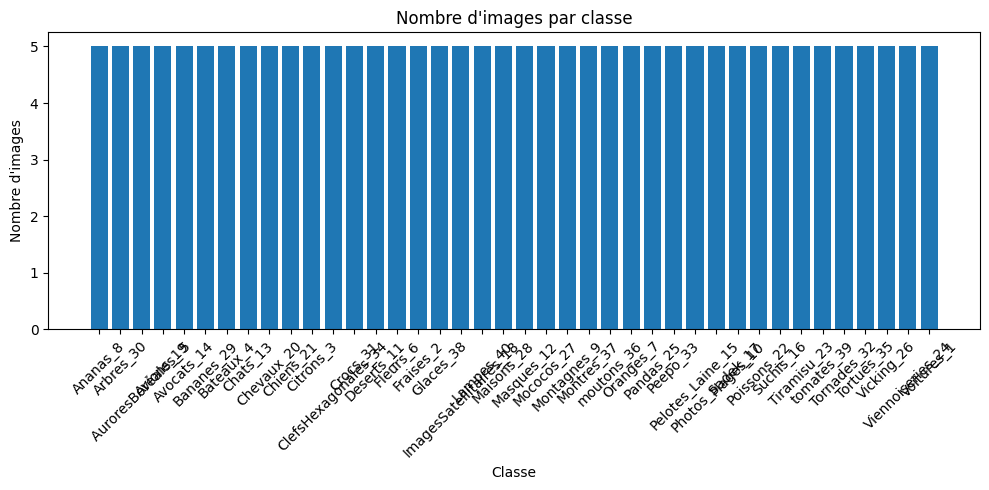

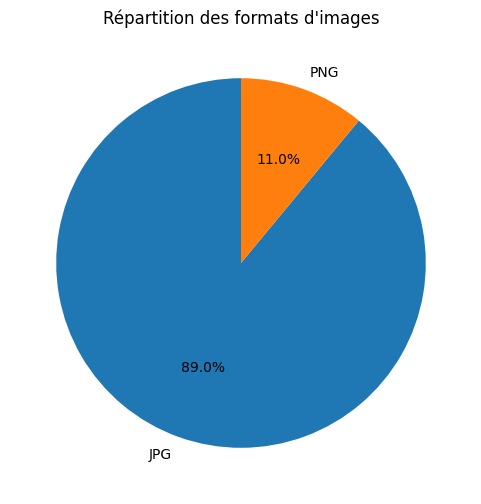

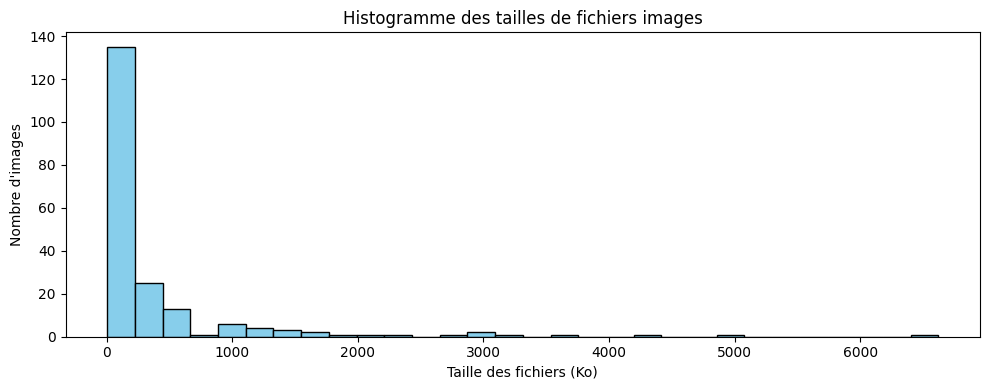

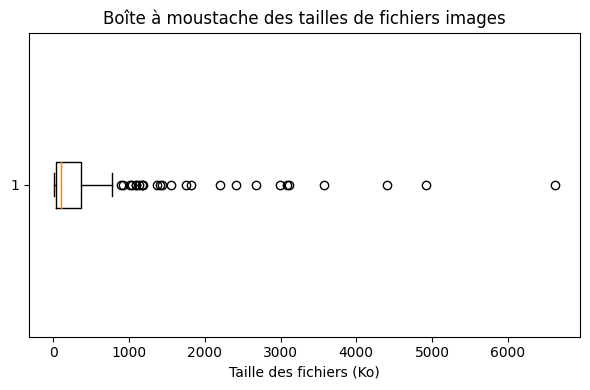

In [ ]:
def compter_classes(base):
    """
    Retourne le nombre total de classes (sous-dossiers) et la liste des noms des classes.
    """
    try:
        classes = [d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]
        return len(classes), classes
    except FileNotFoundError:
        print("Base non trouvée :", base)
        return 0, []
    
def compter_images(base):
    """
    Retourne le nombre total d'images de la base, toutes classes confondues.
    """
    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
    total = 0
    for root, dirs, files in os.walk(base):
        images = [f for f in files if f.lower().endswith(extensions)]
        total += len(images)
    return total

def verifier_cardinalite(base, nbi_cls=5):
    """
    Vérifie que chaque classe contient bien nbi_cls images.
    Affiche un message d’alerte si une classe est incomplète ou contient trop d’images.
    Produit un diagramme en bandes représentant le nombre d’images par classe.
    """
    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
    try:
        classes = [d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]
        nb_images_par_classe = {}
        for classe in classes:
            dossier_classe = os.path.join(base, classe)
            fichiers = os.listdir(dossier_classe)
            images = [f for f in fichiers if f.lower().endswith(extensions)]
            nb_images = len(images)
            nb_images_par_classe[classe] = nb_images
            if nb_images < nbi_cls:
                print(f"ALERTE : Classe '{classe}' incomplète ({nb_images} images, attendu : {nbi_cls})")
            elif nb_images > nbi_cls:
                print(f"ALERTE : Classe '{classe}' trop d'images ({nb_images} images, attendu : {nbi_cls})")
        # Diagramme en bandes
        plt.figure(figsize=(10, 5))
        plt.bar(nb_images_par_classe.keys(), nb_images_par_classe.values())
        plt.xlabel("Classe")
        plt.ylabel("Nombre d'images")
        plt.title("Nombre d'images par classe")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    except FileNotFoundError:
        print("Base non trouvée :", base)

def formats_images(base):
    """
    Calcule la répartition des formats d'images (JPEG, PNG, etc) dans la base
    et affiche les résultats sous forme d’un diagramme circulaire.
    """
    extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.gif']
    formats_count = {ext.upper().replace('.', ''): 0 for ext in extensions}
    for root, dirs, files in os.walk(base):
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            if ext in extensions:
                key = ext.upper().replace('.', '')
                formats_count[key] += 1
    # Retirer les formats non présents
    formats_count = {k: v for k, v in formats_count.items() if v > 0}
    if formats_count:
        plt.figure(figsize=(6, 6))
        plt.pie(formats_count.values(), labels=formats_count.keys(), autopct='%1.1f%%', startangle=90)
        plt.title("Répartition des formats d'images")
        plt.show()
    else:
        print("Aucune image trouvée dans la base.")

def taille_fichiers(base):
    """
    Calcule la répartition des tailles des images en Ko.
    Produit un histogramme des tailles de fichiers et une boîte à moustache pour mettre en évidence les extrêmes.
    """

    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
    tailles = []
    for root, dirs, files in os.walk(base):
        for f in files:
            if f.lower().endswith(extensions):
                chemin = os.path.join(root, f)
                taille_ko = os.path.getsize(chemin) / 1024  # taille en Ko
                tailles.append(taille_ko)

    if tailles:
        plt.figure(figsize=(10, 4))
        plt.hist(tailles, bins=30, color='skyblue', edgecolor='black')
        plt.xlabel("Taille des fichiers (Ko)")
        plt.ylabel("Nombre d'images")
        plt.title("Histogramme des tailles de fichiers images")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.boxplot(tailles, vert=False)
        plt.xlabel("Taille des fichiers (Ko)")
        plt.title("Boîte à moustache des tailles de fichiers images")
        plt.tight_layout()
        plt.show()
    else:
        print("Aucune image trouvée dans la base.")

## compter_classes
nb_classes, noms_classes = compter_classes("BD_images")
print(nb_classes)
print(noms_classes)

## compter_images
nb_images = compter_images("BD_images")
print(nb_images)

## verifier_cardinalite
verifier_cardinalite("BD_images", nbi_cls=5)

## formats_images
formats_images("BD_images")

## taille_fichiers
taille_fichiers("BD_images")

Fonctions d'analyse statistique "avec ouverture des images"

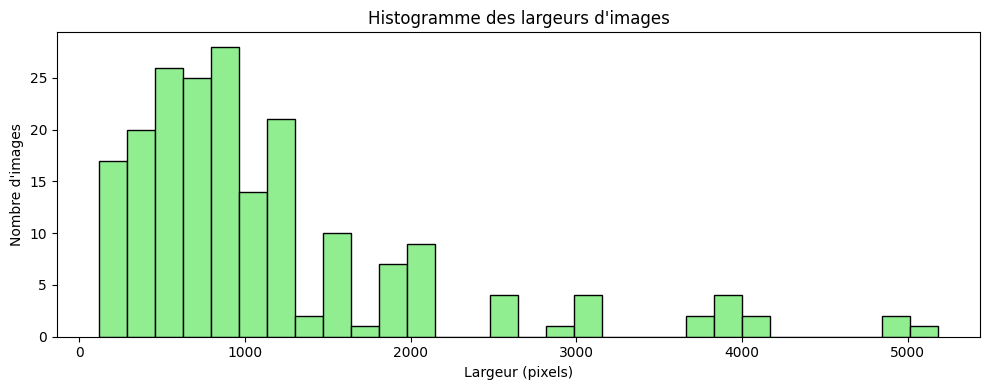

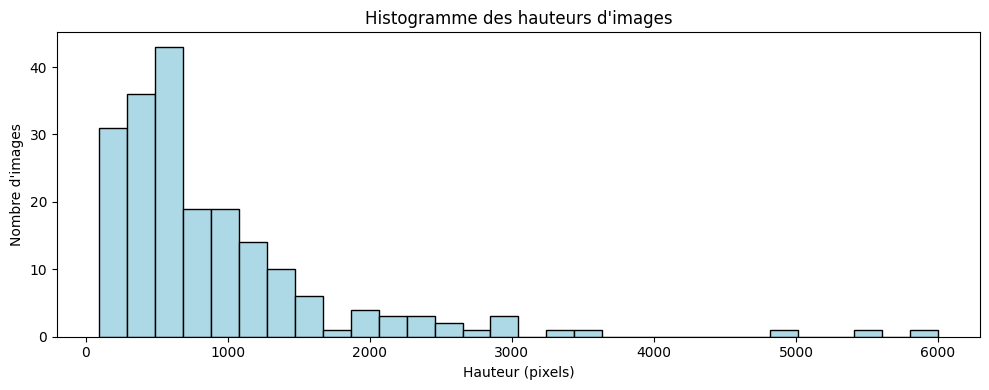

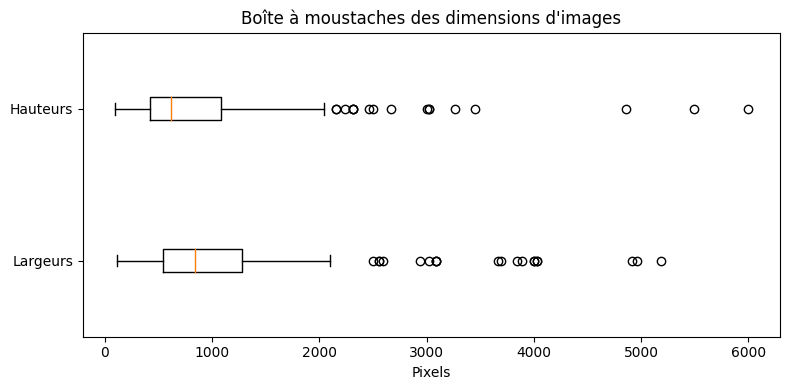

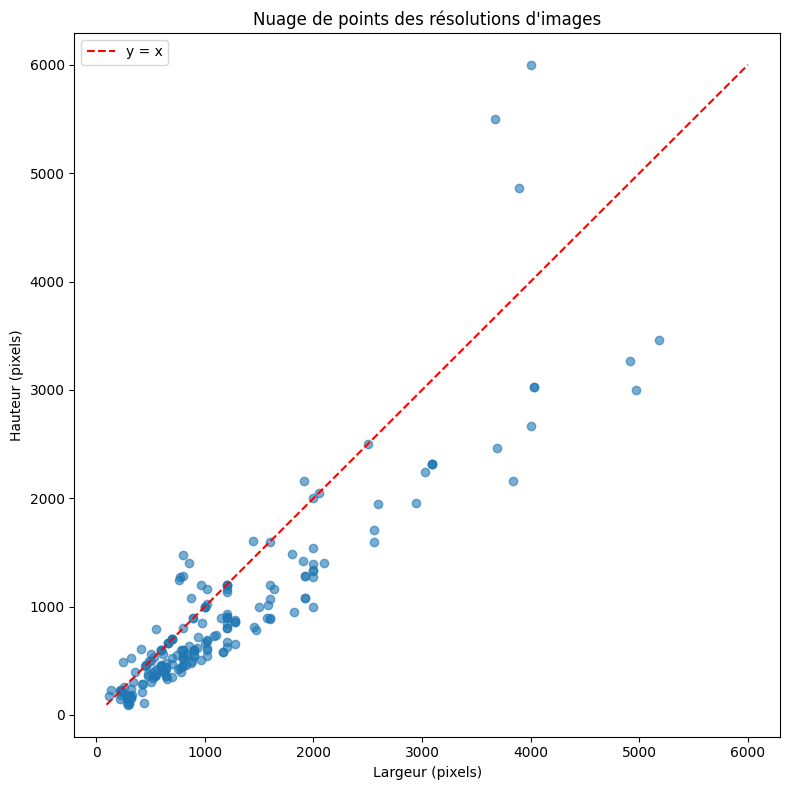

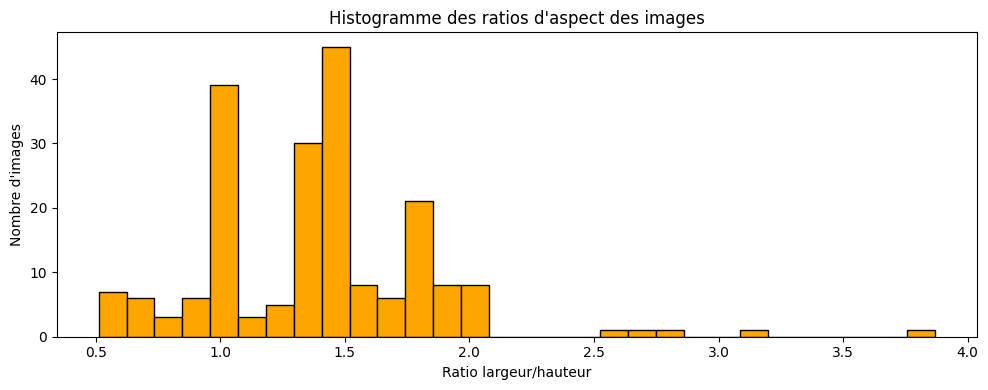

In [24]:
from PIL import Image

def dimensions_images(base):
    """
    Calcule la répartition des largeurs et hauteurs des images.
    Produit un histogramme des largeurs, un histogramme des hauteurs,
    et une boîte à moustaches pour mettre en évidence les extrêmes.
    """
    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
    largeurs = []
    hauteurs = []
    for root, dirs, files in os.walk(base):
        for f in files:
            if f.lower().endswith(extensions):
                chemin = os.path.join(root, f)
                try:
                    with Image.open(chemin) as img:
                        largeur, hauteur = img.size
                        largeurs.append(largeur)
                        hauteurs.append(hauteur)
                except Exception as e:
                    print(f"Erreur ouverture {chemin} : {e}")

    if largeurs and hauteurs:
        plt.figure(figsize=(10, 4))
        plt.hist(largeurs, bins=30, color='lightgreen', edgecolor='black')
        plt.xlabel("Largeur (pixels)")
        plt.ylabel("Nombre d'images")
        plt.title("Histogramme des largeurs d'images")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.hist(hauteurs, bins=30, color='lightblue', edgecolor='black')
        plt.xlabel("Hauteur (pixels)")
        plt.ylabel("Nombre d'images")
        plt.title("Histogramme des hauteurs d'images")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 4))
        plt.boxplot([largeurs, hauteurs], vert=False, labels=["Largeurs", "Hauteurs"])
        plt.xlabel("Pixels")
        plt.title("Boîte à moustaches des dimensions d'images")
        plt.tight_layout()
        plt.show()
    else:
        print("Aucune image trouvée ou aucune dimension extraite.")

def resolutions_images(base):
    """
    Trace un nuage de points (largeur vs hauteur) où chaque point représente une image.
    Ajoute la ligne y = x pour comparer les images carrées et rectangulaires.
    """
    from PIL import Image
    import matplotlib.pyplot as plt
    import os

    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
    largeurs = []
    hauteurs = []
    for root, dirs, files in os.walk(base):
        for f in files:
            if f.lower().endswith(extensions):
                chemin = os.path.join(root, f)
                try:
                    with Image.open(chemin) as img:
                        largeur, hauteur = img.size
                        largeurs.append(largeur)
                        hauteurs.append(hauteur)
                except Exception as e:
                    print(f"Erreur ouverture {chemin} : {e}")

    if largeurs and hauteurs:
        plt.figure(figsize=(8, 8))
        plt.scatter(largeurs, hauteurs, alpha=0.6)
        plt.plot([min(largeurs + hauteurs), max(largeurs + hauteurs)],
                 [min(largeurs + hauteurs), max(largeurs + hauteurs)],
                 color='red', linestyle='--', label='y = x')
        plt.xlabel("Largeur (pixels)")
        plt.ylabel("Hauteur (pixels)")
        plt.title("Nuage de points des résolutions d'images")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Aucune image trouvée ou aucune dimension extraite.")

def ratio_aspect_images(base):
    """
    Calcule le ratio largeur/hauteur de chaque image et trace un histogramme des ratios d’aspect.
    """
    from PIL import Image
    import matplotlib.pyplot as plt
    import os

    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
    ratios = []
    for root, dirs, files in os.walk(base):
        for f in files:
            if f.lower().endswith(extensions):
                chemin = os.path.join(root, f)
                try:
                    with Image.open(chemin) as img:
                        largeur, hauteur = img.size
                        if hauteur != 0:
                            ratios.append(largeur / hauteur)
                except Exception as e:
                    print(f"Erreur ouverture {chemin} : {e}")

    if ratios:
        plt.figure(figsize=(10, 4))
        plt.hist(ratios, bins=30, color='orange', edgecolor='black')
        plt.xlabel("Ratio largeur/hauteur")
        plt.ylabel("Nombre d'images")
        plt.title("Histogramme des ratios d'aspect des images")
        plt.tight_layout()
        plt.show()
    else:
        print("Aucun ratio calculé ou aucune image trouvée.")

## dimensions_images
dimensions_images("BD_images")

## resolutions_images
resolutions_images("BD_images")

## ratio_aspect_images
ratio_aspect_images("BD_images")

Visualier quelques exemples pour identifier les pricipaux défis

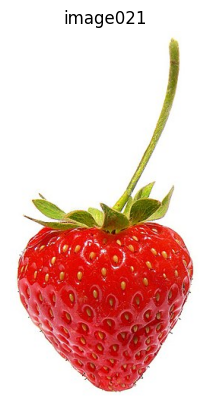

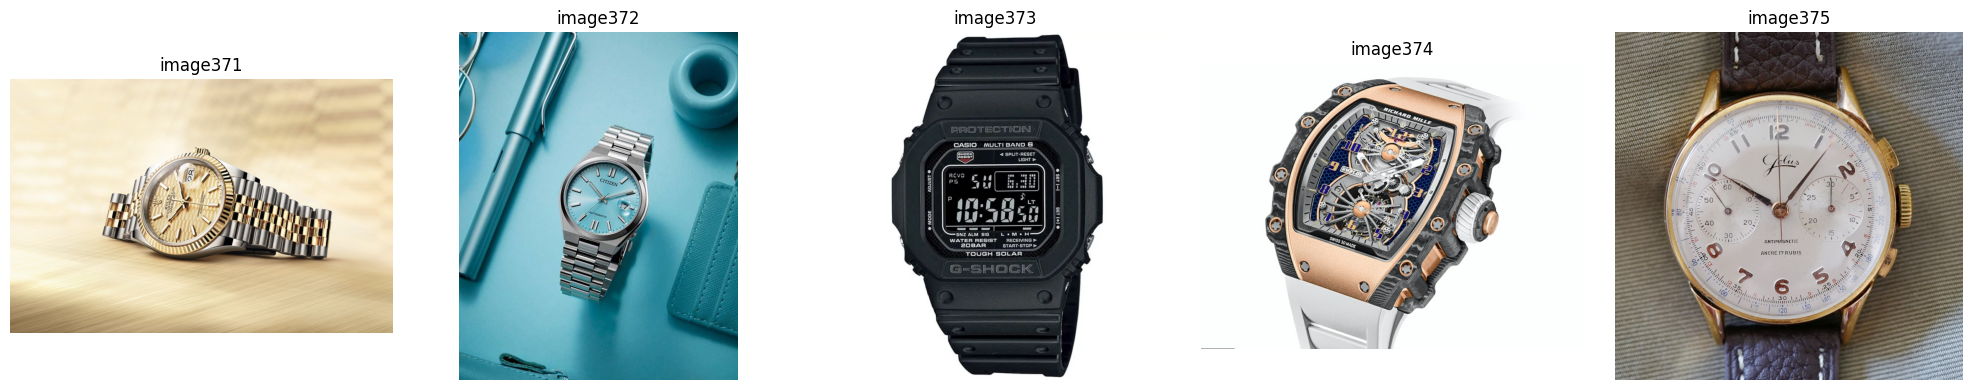

In [ ]:
def afficher_image(classe, base="BD_images"):
    """
    Affiche l'image correspondant à la classe donnée (ex : Montres_371).
    Prend les deux chiffres après le _ pour le nom du dossier (ex : Montres_37).
    Va chercher l'image 'image371.jpg' dans le dossier 'Montres_37'.
    """
    if "_" in classe:
        prefix, numero = classe.rsplit("_", 1)
        dossier_num = numero[:2]  # prend les deux premiers chiffres après le _
        dossier = os.path.join(base, f"{prefix}_{dossier_num}")
        nom_image = f"image{numero}.jpg"
        chemin = os.path.join(dossier, nom_image)
        if os.path.isfile(chemin):
            nom_fichier = os.path.splitext(os.path.basename(chemin))[0]
            try:
                img = Image.open(chemin)
                plt.imshow(img)
                plt.axis('off')
                plt.title(nom_fichier)
                plt.show()
            except Exception as e:
                print(f"Erreur ouverture {chemin} : {e}")
            return
        else:
            print(f"Image non trouvée : {chemin}")
            return

    # Fallback : cherche la première image du dossier
    dossier = os.path.join(base, classe)
    for f in os.listdir(dossier):
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            chemin = os.path.join(dossier, f)
            nom_fichier = os.path.splitext(os.path.basename(chemin))[0]
            try:
                img = Image.open(chemin)
                plt.imshow(img)
                plt.axis('off')
                plt.title(nom_fichier)
                plt.show()
            except Exception as e:
                print(f"Erreur ouverture {chemin} : {e}")
            return
    print(f"Aucune image trouvée pour la classe {classe}")

def afficher_classe(repertoire):
    """
    Affiche toutes les images d’une classe dans une même figure (grille 1×N).
    """
    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
    images = [f for f in os.listdir(repertoire) if f.lower().endswith(extensions)]
    n = len(images)
    if n == 0:
        print("Aucune image trouvée dans le répertoire :", repertoire)
        return

    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for ax, img_name in zip(axes, images):
        chemin = os.path.join(repertoire, img_name)
        try:
            img = Image.open(chemin)
            ax.imshow(img)
            ax.set_title(os.path.splitext(img_name)[0])
            ax.axis('off')
        except Exception as e:
            ax.set_title("Erreur")
            ax.axis('off')
            print(f"Erreur ouverture {chemin} : {e}")
    plt.tight_layout()
    plt.show()

## afficher_image
afficher_image("Fraises_021")

## afficher_classe
afficher_classe("./BD_images/Montres_37")